# 01 — Les données du modèle

Ce que contient le dataset d'entraînement, après préparation (`ml/scripts/donnees.py`).

Prérequis : `python -m ml.scripts.export_dataset`.

In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().resolve().parents[1]))  # racine du projet

import logging

import matplotlib.pyplot as plt
import pandas as pd

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(message)s", force=True)

In [3]:
from ml.scripts.config import CIBLE, FEATURES
from ml.scripts.donnees import preparer
from ml.scripts.export_dataset import lire_dataset

brut = lire_dataset()
df = preparer(brut)
print(f"{len(brut)} campagnes exportées, {len(df)} gardées (pluie connue)")
df[FEATURES + [CIBLE]].head()

INFO Lecture de /home/bhg/Bureau/Projects/Dataflow360/assaman-suuf/data/processed/ml_rendement_campagne_20261007.parquet
INFO 7697 campagnes sur 9894 ont une pluie connue (1937 par la région voisine) ; 2197 écartées


9894 campagnes exportées, 7697 gardées (pluie connue)


,produit,region,saison,systeme_production,annee,superficie_ha,pluie_cumul_mm,tavg_moyenne,cible_rendement_t_ha
0,Niébé,Kaffrine,Principale,Pluvial,2008,1559.041217,867.7,29.100000,0.500000
1,Riz,Kaffrine,Principale,Pluvial,2005,38.195721,594.0,29.130000,1.500000
2,Mil,Kolda,Principale,Pluvial,1999,7999.751060,118.6,28.520000,0.702532
3,Mil,Sedhiou,Principale,Pluvial,1980,7820.759875,465.3,28.120000,0.663709
4,Manioc,Diourbel,Principale,Pluvial,2006,65.000000,714.7,29.858333,3.000000


## Origine du climat

Fatick, Kaffrine et Sedhiou n'ont pas de station : elles prennent le climat de Kaolack ou de Kolda.

In [4]:
pd.crosstab(df["region"], df["source_climat"])

source_climat,mesure,region_voisine
region,,
Dakar,192,0
Diourbel,430,0
Fatick,0,562
Kaffrine,0,698
Kaolack,539,0
Kedougou,520,0
Kolda,726,0
Louga,551,0
Matam,493,0


## Train et test (découpage fait par dbt)

In [5]:
df.groupby("jeu").agg(campagnes=("annee", "size"), debut=("annee", "min"), fin=("annee", "max"))

,campagnes,debut,fin
jeu,,,
test,1241,2011,2015
train,6456,1960,2010


## Le rendement selon la culture

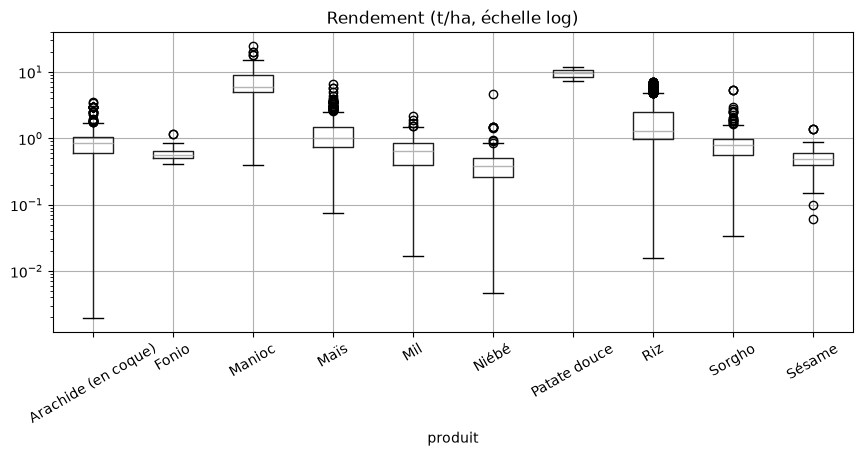

In [6]:
ordre = df.groupby("produit")[CIBLE].median().sort_values().index
df.boxplot(column=CIBLE, by="produit", positions=range(len(ordre)), figsize=(10, 4), rot=30)
plt.yscale("log"); plt.suptitle(""); plt.title("Rendement (t/ha, échelle log)")
plt.show()

## Le rendement selon la pluie (mil)

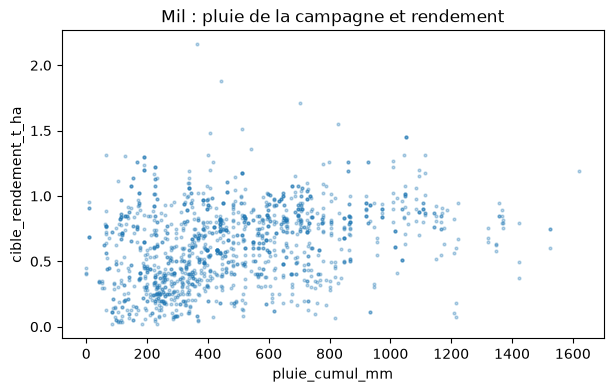

In [7]:
mil = df[df["produit"] == "Mil"]
mil.plot.scatter(x="pluie_cumul_mm", y=CIBLE, s=4, alpha=0.3, figsize=(7, 4), title="Mil : pluie de la campagne et rendement")
plt.show()